# Radio cross-match

Cross-match the OVRO-LWA metacatalog against external radio reference catalogs. Matching is most reliable at similar frequency and angular resolution:

| Catalog | Frequency | Beam | Role |
| --- | --- | --- | --- |
| VLSSR | ~73 MHz | 80″ | Blue-band merge QA (similar freq/resolution) |
| [NVSS](https://heasarc.gsfc.nasa.gov/w3browse/all/nvss.html) | 1.4 GHz | 45″ | Known-source association (Condon et al. 1998) |
| [VLASS QL epoch 1](https://cirada.ca/catalogues) | ~3 GHz | ~2.5″ | Known-source association (Gordon et al. 2021, [ApJS 255, 30](https://scixplorer.org/abs/2021ApJS..255...30G/abstract)) |

Reference catalog files live under `/fast/claw/catalogs/` (see `REFERENCE_CATALOGS_DIR` in `lwa_catalog.constants`).

**Matching:** configurable radius per side (LWA + reference), then pairwise
``sep ≤ max(radius_lwa, radius_ref)`` via ``associate_catalogs``. See
``CrossmatchRadiusSpec`` in the config cell (`mode`: ``beam`` | ``localization`` | ``fixed``).

**Run cells in order.**

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lwa_catalog import CatalogLayout, read_metacatalog, resolve_metacatalog_path
from lwa_catalog.analyze import (
    CrossmatchRadiusSpec,
    LWA_CROSSMATCH_RADIUS_BEAM,
    LWA_CROSSMATCH_RADIUS_LOCALIZATION,
    NVSS_REFERENCE_RADIUS_BEAM,
    VLASS_REFERENCE_RADIUS_BEAM,
    VLSSR_REFERENCE_RADIUS_BEAM,
    NvssMatchConfig,
    VlassMatchConfig,
    VlssrMatchConfig,
    describe_crossmatch_radius,
    filter_or_hesl,
    load_nvss_catalog,
    load_vlass_catalog,
    load_vlssr_catalog,
    match_catalog_to_nvss,
    match_catalog_to_vlass,
    match_catalog_to_vlssr,
    predict_flux_at_frequency_hz,
    resolve_highest_frequency_peak_flux,
    select_metacatalog,
    summarize_nvss_match,
    summarize_vlass_match,
    summarize_vlssr_match,
)
from lwa_catalog.constants import (
    BAND_FREQ_HZ,
    NVSS_BMAJ_ARCSEC,
    NVSS_DEFAULT_PATH,
    NVSS_FREQ_HZ,
    REFERENCE_CATALOGS_DIR,
    VLASS_BMAJ_ARCSEC,
    VLASS_DEFAULT_PATH,
    VLASS_FREQ_HZ,
    VLSSR_BMAJ_ARCSEC,
    VLSSR_DEFAULT_PATH,
)

# --- operator config ---
CATALOG_DIR = Path("/fast/claw/metacatalog_coaddR-0.75")
VLSSR_PATH = VLSSR_DEFAULT_PATH
NVSS_PATH = NVSS_DEFAULT_PATH
VLASS_PATH = VLASS_DEFAULT_PATH
APPLY_OR_HESL_FILTER = True

# Metacatalog subset for NVSS / VLASS cross-match:
#   "full" | "blue" | "quality_all_clear" | "query"
METACATALOG_SELECTION = "blue"
METACATALOG_QUERY = "Peak_flux > 1.0"  # used only when METACATALOG_SELECTION == "query"

# NVSS / VLASS match target: "metacatalog" or "metacatalog_blue"
RADIO_MATCH_TARGET = "metacatalog"

# --- cross-match radius (per catalog side) ---
# mode "beam"           — restoring beam (BMAJ_match / BMAJ); default for surveys
# mode "localization"   — 1σ position error (E_RA/E_DEC, cluster_jitter_rms_deg, or default_arcsec)
# mode "fixed"          — constant fixed_arcsec for every source
# sigma_scale           — multiply beam or 1σ radius (e.g. 3 for 3σ matching)

LWA_MATCH_RADIUS = LWA_CROSSMATCH_RADIUS_BEAM
# LWA_MATCH_RADIUS = LWA_CROSSMATCH_RADIUS_LOCALIZATION
# LWA_MATCH_RADIUS = CrossmatchRadiusSpec(mode="fixed", fixed_arcsec=120.0)

VLSSR_REFERENCE_RADIUS = VLSSR_REFERENCE_RADIUS_BEAM
# VLSSR_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="fixed", fixed_arcsec=VLSSR_BMAJ_ARCSEC)

NVSS_REFERENCE_RADIUS = NVSS_REFERENCE_RADIUS_BEAM
# NVSS_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="fixed", fixed_arcsec=NVSS_BMAJ_ARCSEC)
# NVSS_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="localization", default_arcsec=1.5)

VLASS_REFERENCE_RADIUS = VLASS_REFERENCE_RADIUS_BEAM
# VLASS_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="fixed", fixed_arcsec=VLASS_BMAJ_ARCSEC)
# VLASS_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="localization", default_arcsec=1.0)

layout = CatalogLayout(CATALOG_DIR)
vlssr_config = VlssrMatchConfig(
    catalog_path=VLSSR_PATH,
    target="metacatalog_blue",
    lwa_radius=LWA_MATCH_RADIUS,
    reference_radius=VLSSR_REFERENCE_RADIUS,
)
nvss_config = NvssMatchConfig(
    catalog_path=NVSS_PATH,
    target=RADIO_MATCH_TARGET,
    lwa_radius=LWA_MATCH_RADIUS,
    reference_radius=NVSS_REFERENCE_RADIUS,
)
vlass_config = VlassMatchConfig(
    catalog_path=VLASS_PATH,
    target=RADIO_MATCH_TARGET,
    lwa_radius=LWA_MATCH_RADIUS,
    reference_radius=VLASS_REFERENCE_RADIUS,
)

print("CATALOG_DIR =", layout.root.resolve())
print("metacatalog path =", resolve_metacatalog_path(layout))
print("REFERENCE_CATALOGS_DIR =", REFERENCE_CATALOGS_DIR.resolve())
print("VLSSR_PATH =", Path(VLSSR_PATH).resolve())
print("NVSS_PATH =", Path(NVSS_PATH).resolve())
print("VLASS_PATH =", Path(VLASS_PATH).resolve())
print("APPLY_OR_HESL_FILTER =", APPLY_OR_HESL_FILTER)
print("METACATALOG_SELECTION =", METACATALOG_SELECTION)
print("LWA match radius:", describe_crossmatch_radius(LWA_MATCH_RADIUS))
print("VLSSR reference radius:", describe_crossmatch_radius(VLSSR_REFERENCE_RADIUS))
print("NVSS reference radius:", describe_crossmatch_radius(NVSS_REFERENCE_RADIUS))
print("VLASS reference radius:", describe_crossmatch_radius(VLASS_REFERENCE_RADIUS))

CATALOG_DIR = /fast/claw/metacatalog_coaddR-0.75
metacatalog path = /fast/claw/metacatalog_coaddR-0.75/metacatalog_quality.parquet
REFERENCE_CATALOGS_DIR = /fast/claw/catalogs
VLSSR_PATH = /fast/claw/catalogs/vlssr_radecpeak.txt
NVSS_PATH = /fast/claw/catalogs/nvss/CATALOG.FIT
VLASS_PATH = /fast/claw/catalogs/vlass/CIRADA_VLASS1QLv3.1_table1_components.csv.gz
APPLY_OR_HESL_FILTER = True
METACATALOG_SELECTION = blue


## Load and select metacatalog

In [2]:
metacatalog = read_metacatalog(
    layout,
    prefer_quality=True,
    prefer_spectral=True,
    quality_mask=None,
)
if APPLY_OR_HESL_FILTER:
    metacatalog = filter_or_hesl(metacatalog)
selected_meta = select_metacatalog(
    metacatalog,
    selection=METACATALOG_SELECTION,
    layout=layout,
    query=METACATALOG_QUERY,
)

print(f"metacatalog rows: {len(metacatalog)}")
print(f"selected rows ({METACATALOG_SELECTION}): {len(selected_meta)}")
print(f"spectral columns present: {any(c.startswith('spec_peak_') for c in selected_meta.columns)}")

metacatalog rows: 95938
selected rows (blue): 93560
spectral columns present: False


In [3]:
def build_unique_flux_table(
    selected_meta: pd.DataFrame,
    meta_flags: pd.DataFrame,
    ref_footprint: pd.DataFrame,
    *,
    count_col: str,
    positions_col: str,
    ref_peak_col: str,
    ref_freq_hz: float,
    lwa_flux_col: str,
) -> pd.DataFrame:
    unique_flags = meta_flags.loc[meta_flags[count_col] == 1].copy()
    meta_by_id = selected_meta.set_index("meta_id", drop=False)
    records: list[dict] = []
    for _, flag in unique_flags.iterrows():
        positions = flag.get(positions_col, [])
        if len(positions) != 1:
            continue
        meta_id = flag["meta_id"]
        if meta_id not in meta_by_id.index:
            continue
        meta_row = meta_by_id.loc[meta_id]
        if isinstance(meta_row, pd.DataFrame):
            meta_row = meta_row.iloc[0]
        ref_row = ref_footprint.iloc[int(positions[0])]
        ref_peak = float(ref_row[ref_peak_col])
        lwa_flux = predict_flux_at_frequency_hz(meta_row, ref_freq_hz, flux_kind="peak")
        records.append(
            {
                "meta_id": meta_id,
                "RA": flag["RA"],
                "DEC": flag["DEC"],
                "ref_peak_jy": ref_peak,
                lwa_flux_col: lwa_flux,
                "log_ratio": np.log10(lwa_flux / ref_peak)
                if np.isfinite(lwa_flux) and ref_peak > 0
                else np.nan,
            }
        )
    return pd.DataFrame.from_records(records)


def plot_unique_flux_check(
    flux_table: pd.DataFrame, *, title: str, lwa_flux_col: str, ref_label: str
) -> None:
    finite = flux_table.dropna(subset=["log_ratio"])
    if finite.empty:
        print("No rows with spectral extrapolation for plot.")
        return
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(
        np.log10(finite["ref_peak_jy"]),
        np.log10(finite[lwa_flux_col]),
        s=8,
        alpha=0.35,
    )
    lim = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlabel(f"log10 {ref_label} peak (Jy)")
    ax.set_ylabel(f"log10 LWA extrapolated peak ({lwa_flux_col})")
    ax.set_title(title)
    plt.show()

## VLSSR cross-match (~73 MHz)

Post-hoc QA against the VLSSR reference catalog at similar frequency and resolution to the Blue band.

**Primary metric:** Blue-associated completeness — fraction of rows with `"Blue" in bands_present` that match ≥1 VLSSR source within beam.

**Failure-mode metric:** VLSSR over-splitting — one VLSSR source matched by multiple metacatalog rows.

In [4]:
vlssr = load_vlssr_catalog(VLSSR_PATH)
print(f"VLSSR rows: {len(vlssr):,}")
vlssr_result = match_catalog_to_vlssr(metacatalog, vlssr=vlssr, config=vlssr_config)
print(summarize_vlssr_match(vlssr_result))

VLSSR rows: 92,965
LWA target rows:               93560
VLSSR footprint (Dec box):     92965
Meta matched (>=1 VLSSR):      62708
Blue completeness:            0.670
VLSSR matched (>=1 meta):      72528
VLSSR recovery:               0.780
VLSSR over-split (n_meta>1):    7448
Meta multi-VLSSR (n_vlssr>1):  14164
Max VLSSR hits per meta:           9


In [5]:
vlssr_meta_flags = vlssr_result.meta_flags
vlssr_ref_flags = vlssr_result.vlssr_flags

print("VLSSR hits per meta (value_counts):")
display(vlssr_meta_flags["n_vlssr"].value_counts().sort_index().head(20))

vlssr_incomplete = vlssr_meta_flags.loc[~vlssr_meta_flags["matched"]]
print(f"\nIncomplete Blue-associated rows (no VLSSR match, first 20 of {len(vlssr_incomplete)}):")
display(vlssr_incomplete.head(20))

vlssr_oversplit = vlssr_ref_flags.loc[vlssr_ref_flags["oversplit"]]
print(f"\nVLSSR over-split rows (first 20 of {len(vlssr_oversplit)}):")
display(vlssr_oversplit.head(20))

VLSSR hits per meta (value_counts):


n_vlssr
0    30852
1    48544
2    11231
3     2380
4      456
5       77
6       15
7        4
9        1
Name: count, dtype: int64


Incomplete Blue-associated rows (no VLSSR match, first 20 of 30852):


,meta_id,RA,DEC,n_vlssr,vlssr_positions,matched
2,43,285.702609,-23.499407,0,[],False
8,68,269.657976,-16.315020,0,[],False
9,69,276.225902,-32.716981,0,[],False
17,97,262.447036,-21.209711,0,[],False
33,136,281.124943,-40.387717,0,[],False
36,52951,192.210641,-41.357406,0,[],False
46,161,300.511613,41.554538,0,[],False
48,164,54.661223,-35.384599,0,[],False
55,184,109.260281,-36.341293,0,[],False
58,192,247.155550,14.645569,0,[],False



VLSSR over-split rows (first 20 of 7448):


,vlssr_pos,RA,DEC,Peak_flux,n_meta,meta_ids,oversplit
22,22,0.079685,19.050247,0.896007,2,"[45175, 101126]",True
24,24,0.080179,27.659271,0.579359,2,"[18306, 76164]",True
44,44,0.116363,8.270123,0.542736,2,"[7114, 82288]",True
78,78,0.212157,12.317341,0.685340,2,"[6568, 35301]",True
92,92,0.257089,41.822813,1.335390,2,"[541, 96996]",True
93,93,0.258257,27.597068,0.722256,2,"[18306, 76164]",True
101,101,0.278471,24.343903,0.454628,2,"[83896, 98110]",True
109,109,0.307012,8.331698,2.089117,2,"[7114, 100284]",True
110,110,0.315152,8.523245,0.447888,2,"[7114, 90398]",True
112,112,0.315336,8.777739,4.397699,2,"[6018, 90398]",True


unique VLSSR matches: 48544
with LWA Blue peak flux: 48544


,meta_id,vlssr_peak_jy,lwa_peak_blue_jy,log_ratio
0,38,40.116776,29.847400,-0.128420
1,48,38.946148,13.988382,-0.444697
2,54,39.241577,17.646266,-0.347094
3,59,32.174065,8.323654,-0.587192
4,84,25.452255,0.534646,-1.677660
5,85,29.360842,14.204871,-0.315331
6,86,24.469011,21.157503,-0.063152
7,98,22.853230,8.489781,-0.430051
8,108,27.841808,22.683501,-0.088987
9,52948,30.415533,22.675936,-0.127530


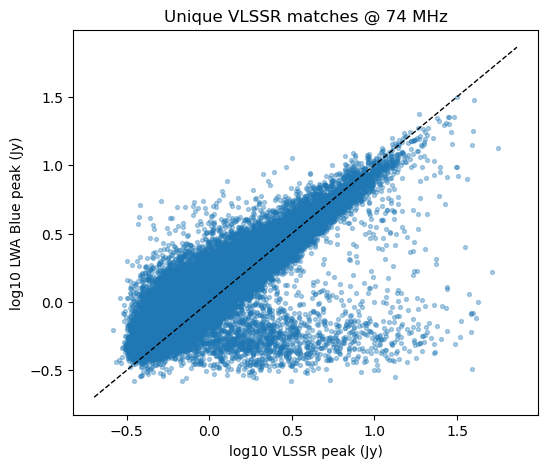

In [6]:
blue_freq_hz = BAND_FREQ_HZ["Blue"]
meta_by_id = metacatalog.set_index("meta_id", drop=False)
vlssr_unique = vlssr_meta_flags.loc[vlssr_meta_flags["n_vlssr"] == 1].copy()

vlssr_flux_records: list[dict] = []
for _, flag in vlssr_unique.iterrows():
    positions = flag.get("vlssr_positions", [])
    if len(positions) != 1:
        continue
    meta_id = flag["meta_id"]
    if meta_id not in meta_by_id.index:
        continue
    meta_row = meta_by_id.loc[meta_id]
    if isinstance(meta_row, pd.DataFrame):
        meta_row = meta_row.iloc[0]
    ref_row = vlssr_result.vlssr_footprint.iloc[int(positions[0])]
    ref_peak = float(ref_row["Peak_flux"])
    lwa_flux, _, _ = resolve_highest_frequency_peak_flux(meta_row)
    vlssr_flux_records.append(
        {
            "meta_id": meta_id,
            "vlssr_peak_jy": ref_peak,
            "lwa_peak_blue_jy": lwa_flux,
            "log_ratio": np.log10(lwa_flux / ref_peak)
            if np.isfinite(lwa_flux) and ref_peak > 0
            else np.nan,
        }
    )

vlssr_flux_table = pd.DataFrame.from_records(vlssr_flux_records)
print(f"unique VLSSR matches: {len(vlssr_unique)}")
print(f"with LWA Blue peak flux: {vlssr_flux_table['lwa_peak_blue_jy'].notna().sum()}")
display(vlssr_flux_table.head(20))

finite = vlssr_flux_table.dropna(subset=["log_ratio"])
if not finite.empty:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(
        np.log10(finite["vlssr_peak_jy"]),
        np.log10(finite["lwa_peak_blue_jy"]),
        s=8,
        alpha=0.35,
    )
    lim = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlabel("log10 VLSSR peak (Jy)")
    ax.set_ylabel("log10 LWA Blue peak (Jy)")
    ax.set_title(f"Unique VLSSR matches @ {blue_freq_hz / 1e6:.0f} MHz")
    plt.show()

## NVSS cross-match (1.4 GHz)

Loads ~1.8M rows from the NRAO FITS table (30–60 s on first read).

In [7]:
nvss = load_nvss_catalog(NVSS_PATH)
print(f"NVSS rows: {len(nvss):,}")
print(f"Dec range: {nvss['DEC'].min():.2f} .. {nvss['DEC'].max():.2f}")
nvss_result = match_catalog_to_nvss(selected_meta, nvss=nvss, config=nvss_config)
print(summarize_nvss_match(nvss_result))

NVSS rows: 1,810,672
Dec range: -40.43 .. 89.82
LWA target rows:               93560
NVSS footprint (Dec box):     1807298
Meta matched (>=1 NVSS):       92592
Match completeness:           0.990
Meta unique match (n=1):        5986
Unique match fraction:        0.064
NVSS matched (>=1 meta):      483718
NVSS recovery:                0.268
NVSS over-split (n_meta>1):    48305
Meta multi-NVSS (n_nvss>1):    86606
Max NVSS hits per meta:          145

NVSS reference frequency:     1.40 GHz


In [8]:
nvss_meta_flags = nvss_result.meta_flags
nvss_flags = nvss_result.nvss_flags

print("NVSS hits per meta (value_counts):")
display(nvss_meta_flags["n_nvss"].value_counts().sort_index().head(20))

nvss_unmatched = nvss_meta_flags.loc[~nvss_meta_flags["matched"]]
print(f"\nUnmatched meta rows (first 20 of {len(nvss_unmatched)}):")
display(nvss_unmatched.head(20))

NVSS hits per meta (value_counts):


n_nvss
0       968
1      5986
2     11963
3     13768
4     12196
5      9805
6      7674
7      6032
8      5093
9      4410
10     3818
11     3248
12     2602
13     1938
14     1397
15      957
16      636
17      386
18      212
19      136
Name: count, dtype: int64


Unmatched meta rows (first 20 of 968):


,meta_id,RA,DEC,n_nvss,nvss_positions,matched
33,136,281.124943,-40.387717,0,[],False
36,52951,192.210641,-41.357406,0,[],False
132,341,54.945209,-40.327202,0,[],False
152,52960,192.198209,-41.169255,0,[],False
386,52981,158.338465,-41.132551,0,[],False
417,52986,21.793150,-41.309603,0,[],False
427,811,295.923407,-40.489370,0,[],False
510,52990,162.148807,-41.234394,0,[],False
627,53002,191.486458,-41.493989,0,[],False
711,53008,188.915717,-41.798626,0,[],False


In [9]:
nvss_flux_table = build_unique_flux_table(
    selected_meta,
    nvss_meta_flags,
    nvss_result.nvss_footprint,
    count_col="n_nvss",
    positions_col="nvss_positions",
    ref_peak_col="Peak_intensity",
    ref_freq_hz=NVSS_FREQ_HZ,
    lwa_flux_col="lwa_peak_1p4ghz_jy",
)
print(f"unique NVSS matches: {(nvss_meta_flags['n_nvss'] == 1).sum()}")
print(f"with spectral extrapolation: {nvss_flux_table['lwa_peak_1p4ghz_jy'].notna().sum()}")
display(nvss_flux_table.head(20))
plot_unique_flux_check(
    nvss_flux_table,
    title="Unique NVSS matches",
    lwa_flux_col="lwa_peak_1p4ghz_jy",
    ref_label="NVSS",
)

unique NVSS matches: 5986
with spectral extrapolation: 0


,meta_id,RA,DEC,ref_peak_jy,lwa_peak_1p4ghz_jy,log_ratio
0,52969,285.521864,-23.679611,0.020723,NaN,NaN
1,53066,262.750163,50.130395,1.164437,NaN,NaN
2,3534,128.104809,32.451893,0.122660,NaN,NaN
3,4042,95.475140,22.103056,0.003958,NaN,NaN
4,4871,282.756985,-33.170089,0.228448,NaN,NaN
5,5840,305.549268,69.555639,0.635613,NaN,NaN
6,53230,7.280538,57.152583,0.004683,NaN,NaN
7,6283,102.002121,-38.506212,0.552516,NaN,NaN
8,53239,110.966231,64.859112,0.002284,NaN,NaN
9,53270,292.499279,-35.961489,0.204909,NaN,NaN


No rows with spectral extrapolation for plot.


## VLASS cross-match (~3 GHz)

Loads the CIRADA QL epoch 1 component table with recommended quality flags (`Duplicate_flag <= 1`, `Quality_flag in (0, 4)`, `S_Code != 'E'`). First read can take several minutes.

In [10]:
vlass = load_vlass_catalog(VLASS_PATH, config=vlass_config)
print(f"VLASS rows (after quality filter): {len(vlass):,}")
print(f"Dec range: {vlass['DEC'].min():.2f} .. {vlass['DEC'].max():.2f}")
vlass_result = match_catalog_to_vlass(selected_meta, vlass=vlass, config=vlass_config)
print(summarize_vlass_match(vlass_result))

VLASS rows (after quality filter): 1,874,645
Dec range: -40.02 .. 89.82
LWA target rows:               93560
VLASS footprint (Dec box):    1874458
Meta matched (>=1 VLASS):      91519
Match completeness:           0.978
Meta unique match (n=1):        4278
Unique match fraction:        0.046
VLASS matched (>=1 meta):     562365
VLASS recovery:               0.300
VLASS over-split (n_meta>1):   56386
Meta multi-VLASS (n_vlass>1):  87241
Max VLASS hits per meta:          43

VLASS reference frequency:    3.00 GHz


In [11]:
vlass_meta_flags = vlass_result.meta_flags
vlass_ref_flags = vlass_result.vlass_flags

print("VLASS hits per meta (value_counts):")
display(vlass_meta_flags["n_vlass"].value_counts().sort_index().head(20))

vlass_unmatched = vlass_meta_flags.loc[~vlass_meta_flags["matched"]]
print(f"\nUnmatched meta rows (first 20 of {len(vlass_unmatched)}):")
display(vlass_unmatched.head(20))

vlass_oversplit = vlass_ref_flags.loc[vlass_ref_flags["oversplit"]]
print(f"\nVLASS over-split rows (first 20 of {len(vlass_oversplit)}):")
display(vlass_oversplit.head(20))

VLASS hits per meta (value_counts):


n_vlass
0      2041
1      4278
2      8404
3     10716
4     11151
5      9911
6      8263
7      6849
8      5463
9      4677
10     3895
11     3539
12     3114
13     2595
14     2170
15     1773
16     1392
17     1032
18      743
19      497
Name: count, dtype: int64


Unmatched meta rows (first 20 of 2041):


,meta_id,RA,DEC,n_vlass,vlass_positions,matched
33,136,281.124943,-40.387717,0,[],False
36,52951,192.210641,-41.357406,0,[],False
66,209,329.211368,-18.238732,0,[],False
103,289,202.758499,30.513405,0,[],False
108,299,80.278967,16.639226,0,[],False
132,341,54.945209,-40.327202,0,[],False
152,52960,192.198209,-41.169255,0,[],False
229,511,250.724558,39.811867,0,[],False
298,613,91.052449,-31.934078,0,[],False
312,634,141.752428,39.047463,0,[],False



VLASS over-split rows (first 20 of 56386):


,vlass_pos,RA,DEC,Peak_flux,Component_name,n_meta,meta_ids,oversplit
406,406,152.815152,1.111836,230.763233,VLASS1QLCIR J101115.63+010642.6,2,"[14057, 25522]",True
461,461,37.717926,5.983434,1.248656,VLASS1QLCIR J023052.30+055900.3,2,"[17193, 91267]",True
465,465,37.780509,6.015768,1.008168,VLASS1QLCIR J023107.32+060056.7,2,"[17193, 91267]",True
691,691,260.626950,36.040120,0.672736,VLASS1QLCIR J172230.46+360224.4,2,"[15167, 52467]",True
692,692,260.665039,36.058106,0.867358,VLASS1QLCIR J172239.60+360329.1,2,"[15167, 52467]",True
742,742,188.171490,11.216304,0.964472,VLASS1QLCIR J123241.15+111258.6,2,"[55782, 65822]",True
747,747,188.236590,11.390150,1.097557,VLASS1QLCIR J123256.78+112324.5,2,"[55670, 55782]",True
750,750,188.281951,11.033450,3.010716,VLASS1QLCIR J123307.66+110200.4,2,"[55782, 63147]",True
751,751,188.282941,11.034619,2.444755,VLASS1QLCIR J123307.90+110204.6,2,"[55782, 63147]",True
829,829,279.208016,60.218991,1.790130,VLASS1QLCIR J183649.92+601308.3,2,"[4988, 34833]",True


In [12]:
vlass_flux_table = build_unique_flux_table(
    selected_meta,
    vlass_meta_flags,
    vlass_result.vlass_footprint,
    count_col="n_vlass",
    positions_col="vlass_positions",
    ref_peak_col="Peak_flux",
    ref_freq_hz=VLASS_FREQ_HZ,
    lwa_flux_col="lwa_peak_3ghz_jy",
)
print(f"unique VLASS matches: {(vlass_meta_flags['n_vlass'] == 1).sum()}")
print(f"with spectral extrapolation: {vlass_flux_table['lwa_peak_3ghz_jy'].notna().sum()}")
display(vlass_flux_table.head(20))
plot_unique_flux_check(
    vlass_flux_table,
    title="Unique VLASS matches",
    lwa_flux_col="lwa_peak_3ghz_jy",
    ref_label="VLASS",
)

unique VLASS matches: 4278
with spectral extrapolation: 0


,meta_id,RA,DEC,ref_peak_jy,lwa_peak_3ghz_jy,log_ratio
0,52969,285.521864,-23.679611,1.506279,NaN,NaN
1,52979,104.129038,53.949908,27.716049,NaN,NaN
2,782,35.203265,62.427956,22.624399,NaN,NaN
3,817,36.163846,40.148250,0.899145,NaN,NaN
4,53000,277.750059,-36.001827,4.833579,NaN,NaN
5,1506,263.239268,-13.105286,35.746647,NaN,NaN
6,1515,121.806014,-33.491137,1.490167,NaN,NaN
7,2235,172.381682,0.267566,2.226199,NaN,NaN
8,2581,63.776048,-20.359225,1.119221,NaN,NaN
9,3102,248.617613,62.769264,4.993479,NaN,NaN


No rows with spectral extrapolation for plot.
